In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from datetime import datetime

In [2]:
def parse_log_line(line):
    pattern = r'(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}).*?(\w+)\[(\d+)\]: (.+)'
    match = re.match(pattern, line)
    if match:
        return {
            'timestamp': match.group(1),
            'service': match.group(2),
            'pid': match.group(3),
            'message': match.group(4)
        }
    return None

# Load the log file
lines = []
with open('/var/log/auth.log', 'r') as f:
    for line in f:
        parsed = parse_log_line(line.strip())
        if parsed:
            lines.append(parsed)

df = pd.DataFrame(lines)
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(df.shape)
print(df.head())

(187, 4)
            timestamp service  pid  \
0 2026-05-10 12:33:38  logind  202   
1 2026-05-10 12:33:43   login  391   
2 2026-05-10 12:33:43   login  391   
3 2026-05-10 12:33:44   login  391   
4 2026-05-10 12:33:44  logind  202   

                                             message  
0                                    New seat seat0.  
1  PAM unable to dlopen(pam_lastlog.so): /usr/lib...  
2           PAM adding faulty module: pam_lastlog.so  
3  pam_unix(login:session): session opened for us...  
4                        New session 1 of user root.  


In [3]:
print(df['service'].value_counts())

service
CRON        68
logind      46
login       38
usermod     20
polkitd      8
groupadd     3
useradd      1
passwd       1
chfn         1
gpasswd      1
Name: count, dtype: int64


In [4]:
# Filter for security-relevant events
security_keywords = ['failed', 'failure', 'invalid', 'error', 'sudo', 'root', 'session opened', 'session closed']

def flag_security(message):
    message_lower = message.lower()
    for keyword in security_keywords:
        if keyword in message_lower:
            return keyword
    return 'normal'

df['event_type'] = df['message'].apply(flag_security)
print(df['event_type'].value_counts())

event_type
normal            100
root               75
session opened     10
sudo                2
Name: count, dtype: int64


In [5]:
# Feature Engineering
df['hour'] = df['timestamp'].dt.hour
df['is_night'] = df['hour'].apply(lambda x: 1 if 2 <= x <= 5 else 0)
df['is_root'] = df['message'].apply(lambda x: 1 if 'root' in x.lower() else 0)
df['is_sudo'] = df['message'].apply(lambda x: 1 if 'sudo' in x.lower() else 0)
df['is_failed'] = df['message'].apply(lambda x: 1 if 'failed' in x.lower() or 'failure' in x.lower() else 0)
df['is_new_user'] = df['service'].apply(lambda x: 1 if x in ['useradd', 'usermod', 'groupadd'] else 0)

print(df[['timestamp', 'hour', 'is_night', 'is_root', 'is_sudo', 'is_failed', 'is_new_user']].head(10))
print("\nFeature summary:")
print(df[['is_night', 'is_root', 'is_sudo', 'is_failed', 'is_new_user']].sum())

            timestamp  hour  is_night  is_root  is_sudo  is_failed  \
0 2026-05-10 12:33:38    12         0        0        0          0   
1 2026-05-10 12:33:43    12         0        0        0          0   
2 2026-05-10 12:33:43    12         0        0        0          0   
3 2026-05-10 12:33:44    12         0        1        0          0   
4 2026-05-10 12:33:44    12         0        1        0          0   
5 2026-05-10 12:33:44    12         0        1        0          0   
6 2026-05-10 12:34:01    12         0        0        0          0   
7 2026-05-10 12:34:01    12         0        0        0          0   
8 2026-05-10 12:40:54    12         0        0        0          0   
9 2026-05-10 12:40:55    12         0        0        0          0   

   is_new_user  
0            0  
1            0  
2            0  
3            0  
4            0  
5            0  
6            0  
7            0  
8            0  
9            0  

Feature summary:
is_night       49
is_roo

In [6]:
def detect_anomaly(row):
    reasons = []
    
    if row['is_night'] and row['is_root']:
        reasons.append('root login at night')
    if row['is_sudo'] and row['is_failed']:
        reasons.append('failed sudo attempt')
    if row['is_new_user']:
        reasons.append('user/group modification')
    if row['is_root'] and row['is_new_user']:
        reasons.append('root creating new user')
        
    return ', '.join(reasons) if reasons else 'normal'

df['anomaly_reason'] = df.apply(detect_anomaly, axis=1)
anomalies = df[df['anomaly_reason'] != 'normal']
print(f"Total anomalies flagged: {len(anomalies)}")
print(anomalies[['timestamp', 'service', 'message', 'anomaly_reason']].head(10))

Total anomalies flagged: 44
             timestamp   service  \
14 2026-05-10 12:41:00  groupadd   
15 2026-05-10 12:41:00  groupadd   
16 2026-05-10 12:41:00  groupadd   
17 2026-05-10 12:41:00   useradd   
21 2026-05-10 12:42:54   usermod   
22 2026-05-10 12:42:54   usermod   
23 2026-05-10 12:42:54   usermod   
24 2026-05-10 12:42:54   usermod   
25 2026-05-10 12:42:54   usermod   
26 2026-05-10 12:42:54   usermod   

                                              message           anomaly_reason  
14  group added to /etc/group: name=rmp1931, GID=1000  user/group modification  
15          group added to /etc/gshadow: name=rmp1931  user/group modification  
16                  new group: name=rmp1931, GID=1000  user/group modification  
17  new user: name=rmp1931, UID=1000, GID=1000, ho...  user/group modification  
21                       add 'rmp1931' to group 'adm'  user/group modification  
22                   add 'rmp1931' to group 'dialout'  user/group modification  
23      

In [7]:
from sklearn.ensemble import IsolationForest

# Feature matrix for ML
features = ['hour', 'is_night', 'is_root', 'is_sudo', 'is_failed', 'is_new_user']
X = df[features]

# Train Isolation Forest
iso = IsolationForest(contamination=0.1, random_state=42)
df['ml_anomaly'] = iso.fit_predict(X)
df['ml_anomaly'] = df['ml_anomaly'].apply(lambda x: 1 if x == -1 else 0)

print(f"ML flagged anomalies: {df['ml_anomaly'].sum()}")

# Combine rule-based + ML
df['hybrid_anomaly'] = df.apply(
    lambda row: 1 if (row['anomaly_reason'] != 'normal' or row['ml_anomaly'] == 1) else 0, axis=1
)
print(f"Hybrid detector flagged: {df['hybrid_anomaly'].sum()}")

ML flagged anomalies: 13
Hybrid detector flagged: 53


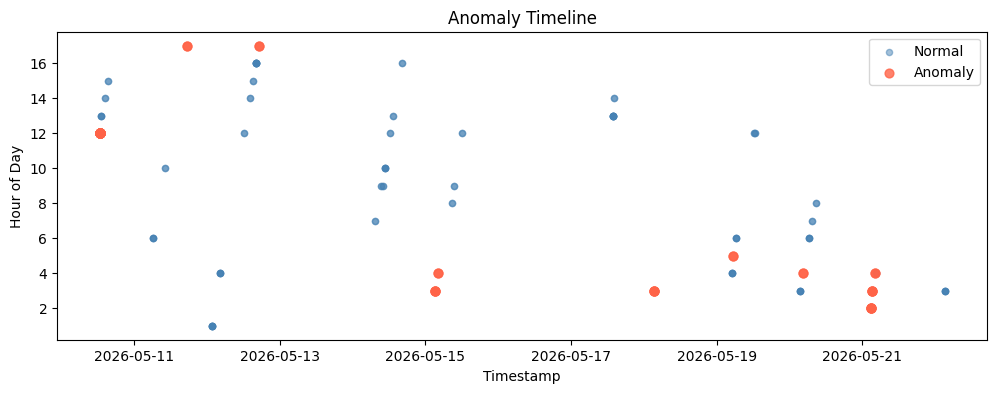

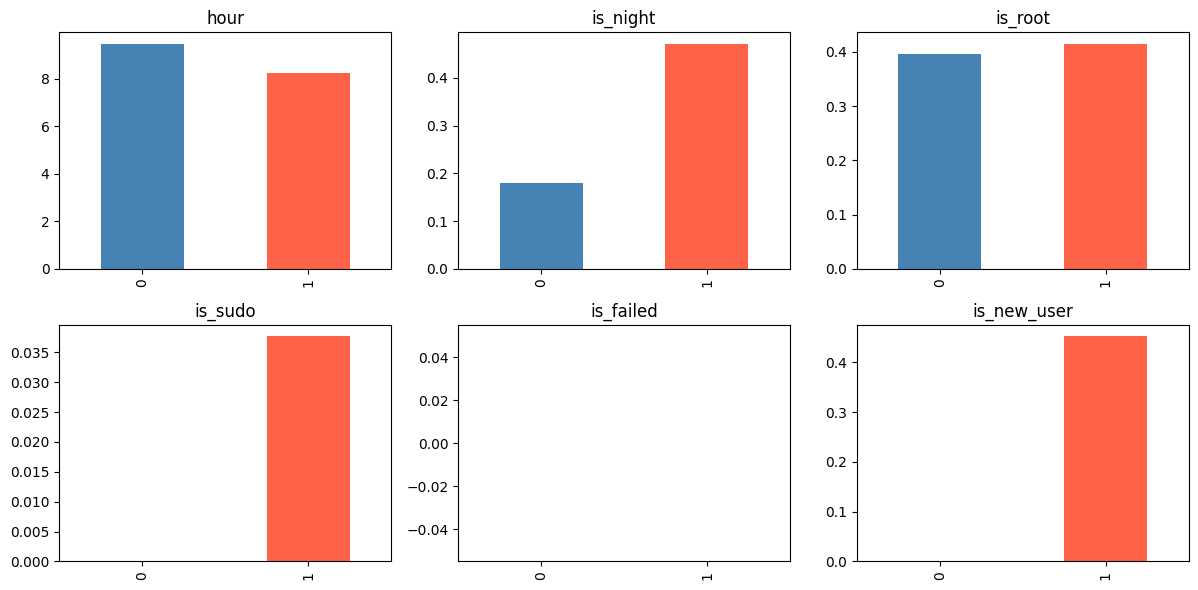


Anomaly breakdown:
anomaly_reason
user/group modification    24
root login at night        20
normal                      9
Name: count, dtype: int64


In [8]:
# 1. Anomaly timeline
plt.figure(figsize=(12, 4))
plt.scatter(df[df['hybrid_anomaly']==0]['timestamp'], 
            df[df['hybrid_anomaly']==0]['hour'],
            c='steelblue', alpha=0.5, label='Normal', s=20)
plt.scatter(df[df['hybrid_anomaly']==1]['timestamp'], 
            df[df['hybrid_anomaly']==1]['hour'],
            c='tomato', alpha=0.8, label='Anomaly', s=40)
plt.xlabel('Timestamp')
plt.ylabel('Hour of Day')
plt.title('Anomaly Timeline')
plt.legend()
plt.savefig('results/anomaly_timeline.png', bbox_inches='tight')
plt.show()

# 2. Feature distribution
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
features = ['hour', 'is_night', 'is_root', 'is_sudo', 'is_failed', 'is_new_user']
for ax, feat in zip(axes.flatten(), features):
    df.groupby('hybrid_anomaly')[feat].mean().plot(kind='bar', ax=ax, color=['steelblue','tomato'])
    ax.set_title(feat)
    ax.set_xlabel('')
plt.tight_layout()
plt.savefig('results/feature_distribution.png', bbox_inches='tight')
plt.show()

# 3. Anomaly summary
print("\nAnomaly breakdown:")
print(df[df['hybrid_anomaly']==1]['anomaly_reason'].value_counts())